# Compare parameter estimation via stepwise BFGS with evofr

In [22]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import evofr as ef

from viral_variant_comp.simulate_count_data import create_count_data, convert_count_data_to_df, prepare_count_data_evofr
from viral_variant_comp.plotting import plot_viral_composition, plot_confidence_intervals, plot_heatmap
from viral_variant_comp.estimate import calculate_viral_composition, evaluate_result, calculate_viral_composition_stepwise, reorder_variants, calculateHessian, calculate_cooccurence, calculate_frequencies

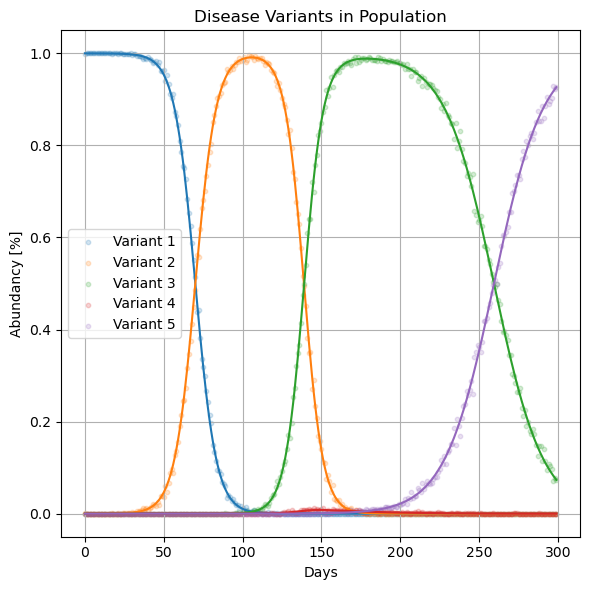

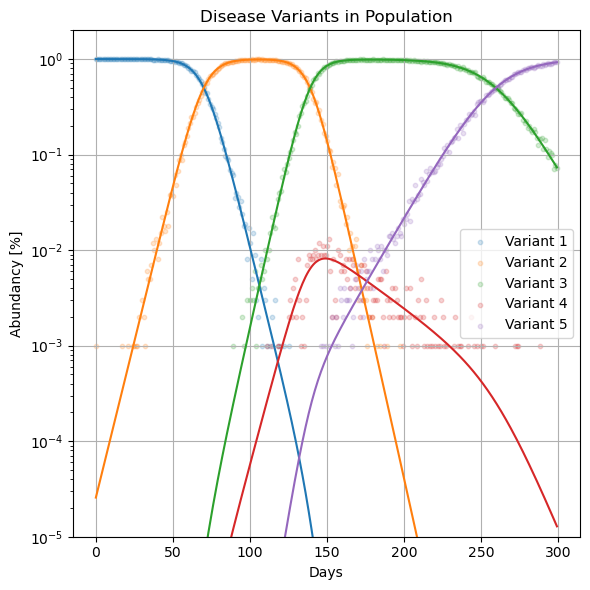

In [25]:
n_variants = 5
n_days = 300
n_samples = 1000

delta_gr_range = 0.2
s_0 = 0.
o_0 = 0.
rate = 1/14  # per day, on average one new variant every two weeks
freq_entering_variants = 0.0001

data = create_count_data(n_variants = n_variants, n_days = n_days, delta_gr_range = delta_gr_range, new_var_rate = rate, freq_entering_variants = freq_entering_variants, n_samples = n_samples, s_0 = s_0, o_0 = o_0)
plot_viral_composition(data['counts'], data['freq'], n_samples, logscale = False)
plot_viral_composition(data['counts'], data['freq'], n_samples, y_range = (1e-5, 2), logscale = True)

#np.savez('data/data_50var_1000days_1000samples.npz', **data)

In [26]:
counts_df = prepare_count_data_evofr(data['counts'])
counts_df.head()

,date,variant,sequences
0,2024-12-31,variant_0,999
1,2025-01-01,variant_0,1000
2,2025-01-02,variant_0,1000
3,2025-01-03,variant_0,1000
4,2025-01-04,variant_0,1000


In [28]:
counts_df.variant.unique()

array(['variant_0', 'variant_1', 'variant_2', 'variant_3', 'variant_4'],
      dtype=object)

In [29]:
def infer_parameters_forecast_evofr(counts):

    variant_frequencies = ef.VariantFrequencies(counts, pivot="variant_0")

    mlr = ef.MultinomialLogisticRegression(tau=1) # tau: average generation time (1 day)
    inference_method = ef.InferNUTS(num_samples=1000, num_warmup=1000) # num_warmup defines burn in

    posterior = inference_method.fit(mlr, variant_frequencies)

    return posterior

posterior = infer_parameters_forecast_evofr(counts_df)

sample: 100%|██████████| 2000/2000 [00:40<00:00, 49.52it/s, 1023 steps of size 5.14e-08. acc. prob=0.81]


In [7]:
#posterior.save_posterior("data/posterior_50var_1000days_1000samples.pkl")

In [ ]:
# reload data and posterior

#data = np.load('data/data_50var_1000days_1000samples.npz')
#variant_frequencies = ef.VariantFrequencies(data['counts'], pivot="variant_0")
#posterior = ef.PosteriorHandler(data=variant_frequencies).load_posterior("data/mlr_estimates.pkl")

In [32]:
freq_estimate.shape

(300, 5)

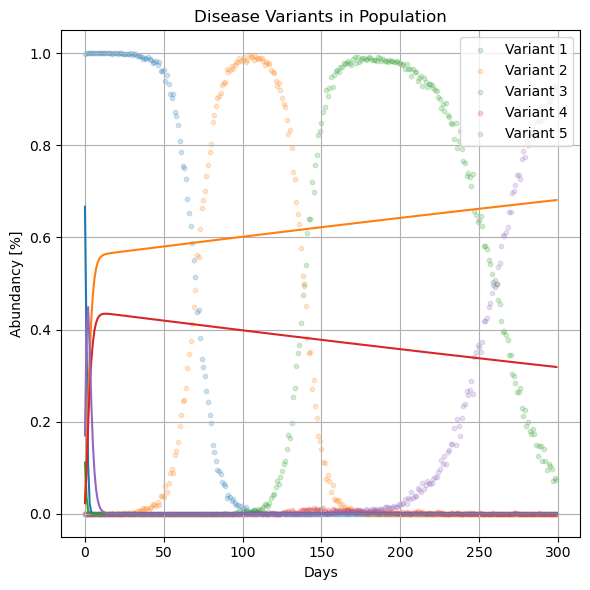

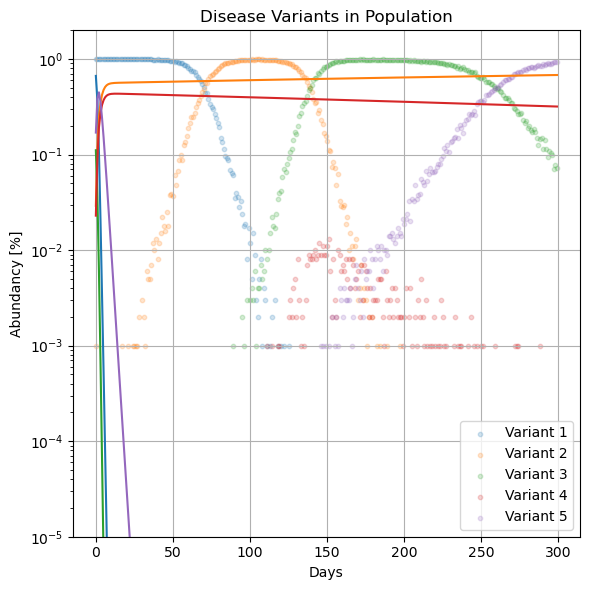

In [30]:
#o_vec = np.median(posterior.samples['beta'][:,0,:], axis = 0)
#s_vec = np.median(posterior.samples['beta'][:,1,:], axis = 0)
freq_estimate = np.median(posterior.samples['freq'], axis = 0)

#composition_estimate = calculate_frequencies(data['counts'].shape[0], s_vec, o_vec) 

plot_viral_composition(data['counts'], freq_estimate, n_samples, logscale = False)
plot_viral_composition(data['counts'], freq_estimate, n_samples, y_range = (1e-5, 2), logscale = True)

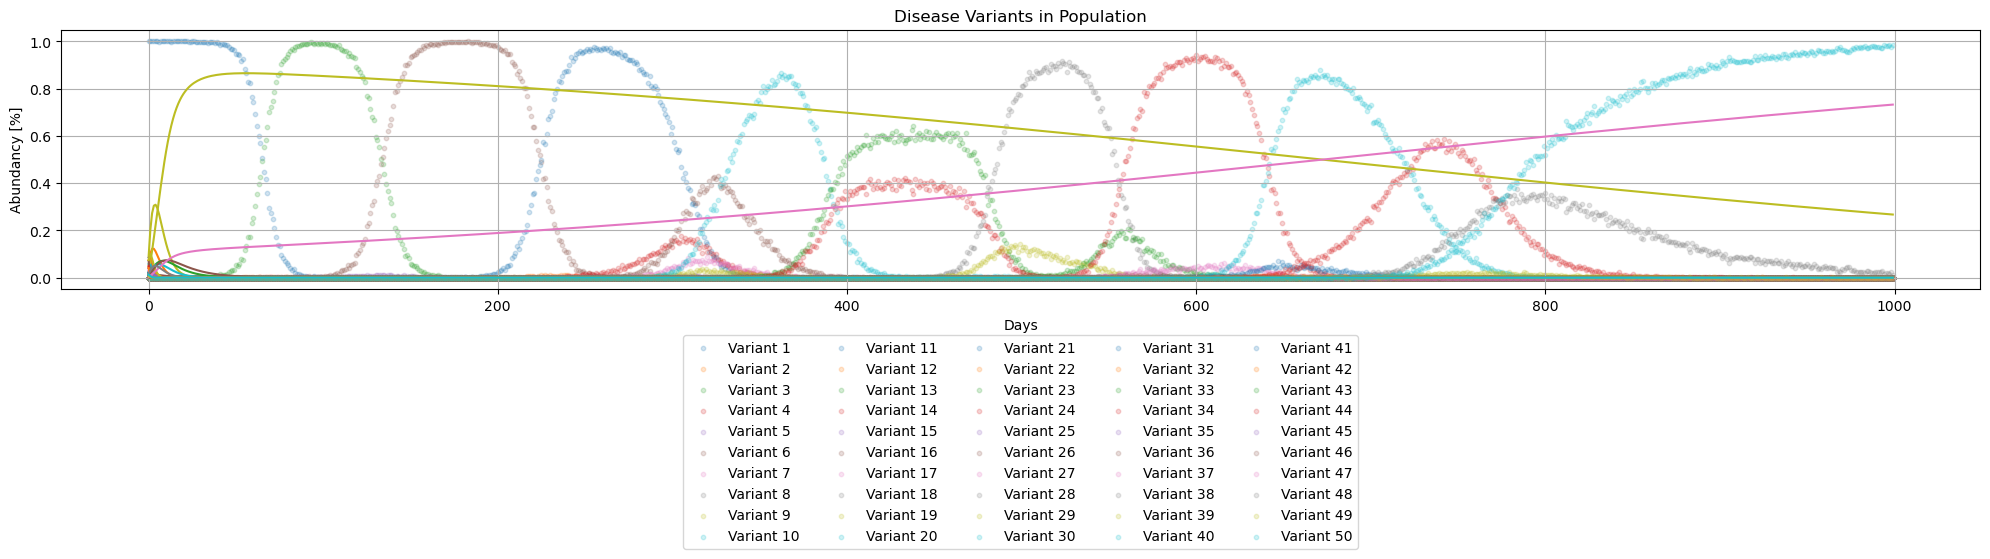

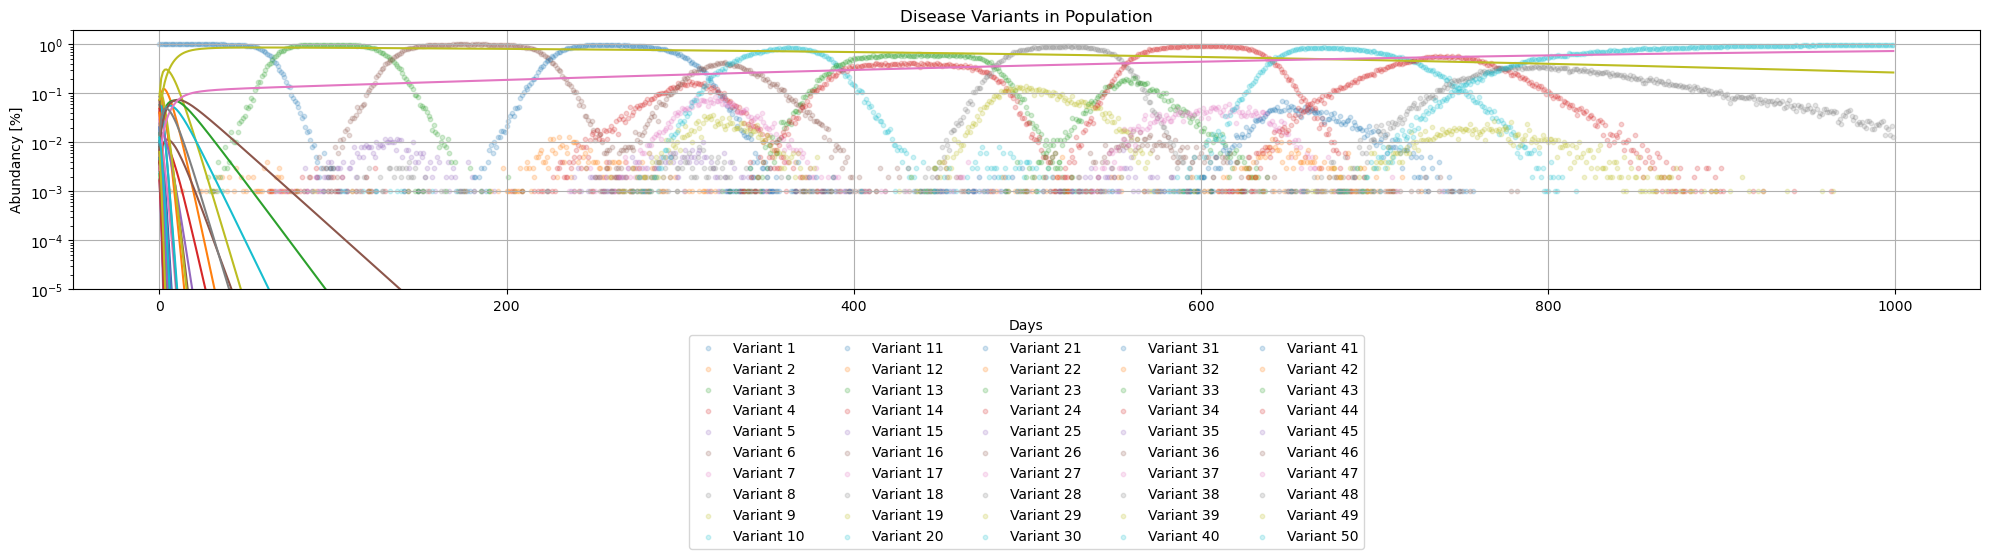

In [9]:
o_vec = np.median(posterior.samples['beta'][:,0,:], axis = 0)
s_vec = np.median(posterior.samples['beta'][:,1,:], axis = 0)
freq_estimate = np.median(posterior.samples['freq'], axis = 0)

#composition_estimate = calculate_frequencies(data['counts'].shape[0], s_vec, o_vec) 

plot_viral_composition(data['counts'], freq_estimate, n_samples, logscale = False)
plot_viral_composition(data['counts'], freq_estimate, n_samples, y_range = (1e-5, 2), logscale = True)

In [38]:
np.median(posterior.samples['freq'], axis = 0)

array([[0.00436604, 0.05010713, 0.00877927, ..., 0.01439525, 0.00639063,
        0.0124165 ],
       [0.00276458, 0.10336266, 0.00199053, ..., 0.03335522, 0.00139726,
        0.00693327],
       [0.00108098, 0.13166733, 0.0002787 , ..., 0.04772637, 0.00018865,
        0.00239071],
       ...,
       [0.        , 0.        , 0.        , ..., 0.16817677, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.16809304, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.16802299, 0.        ,
        0.        ]], shape=(1000, 50), dtype=float32)

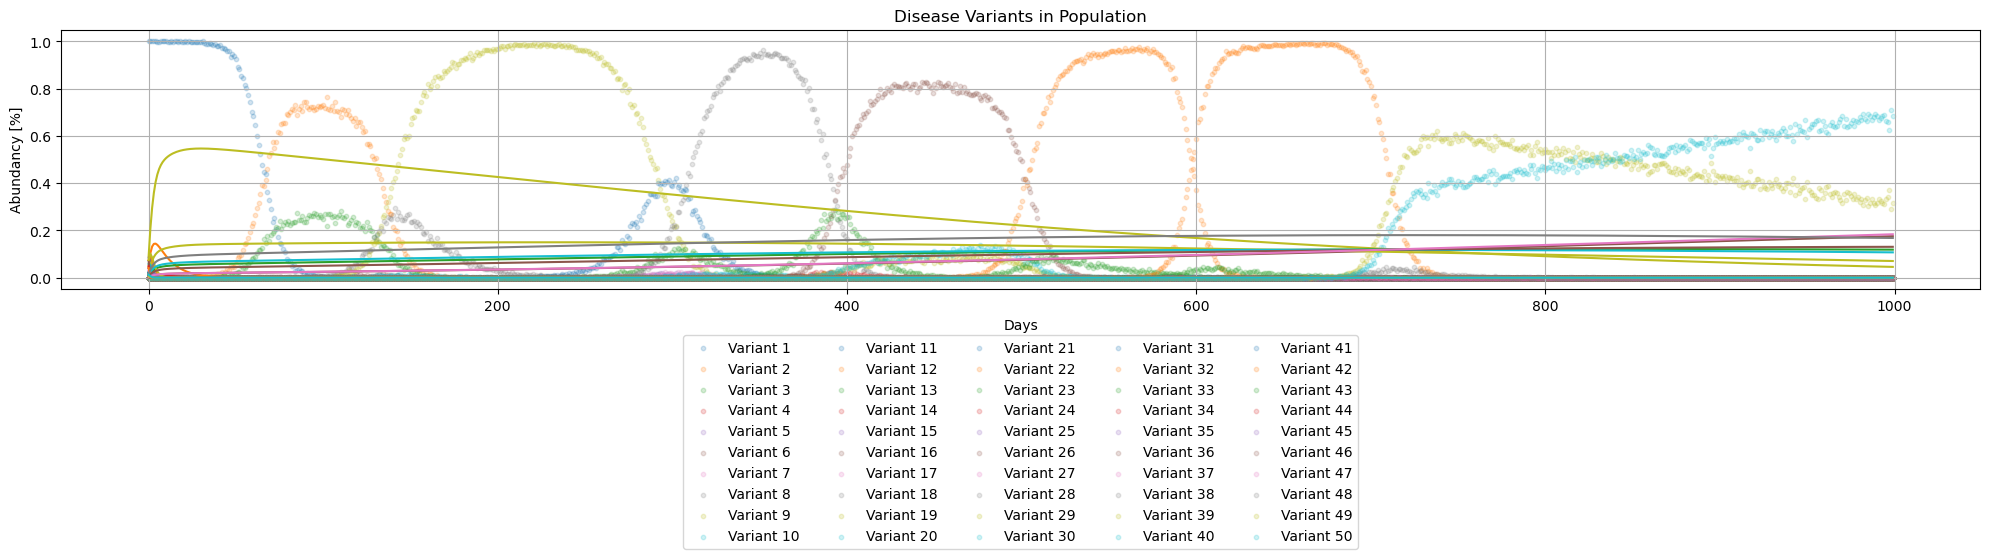

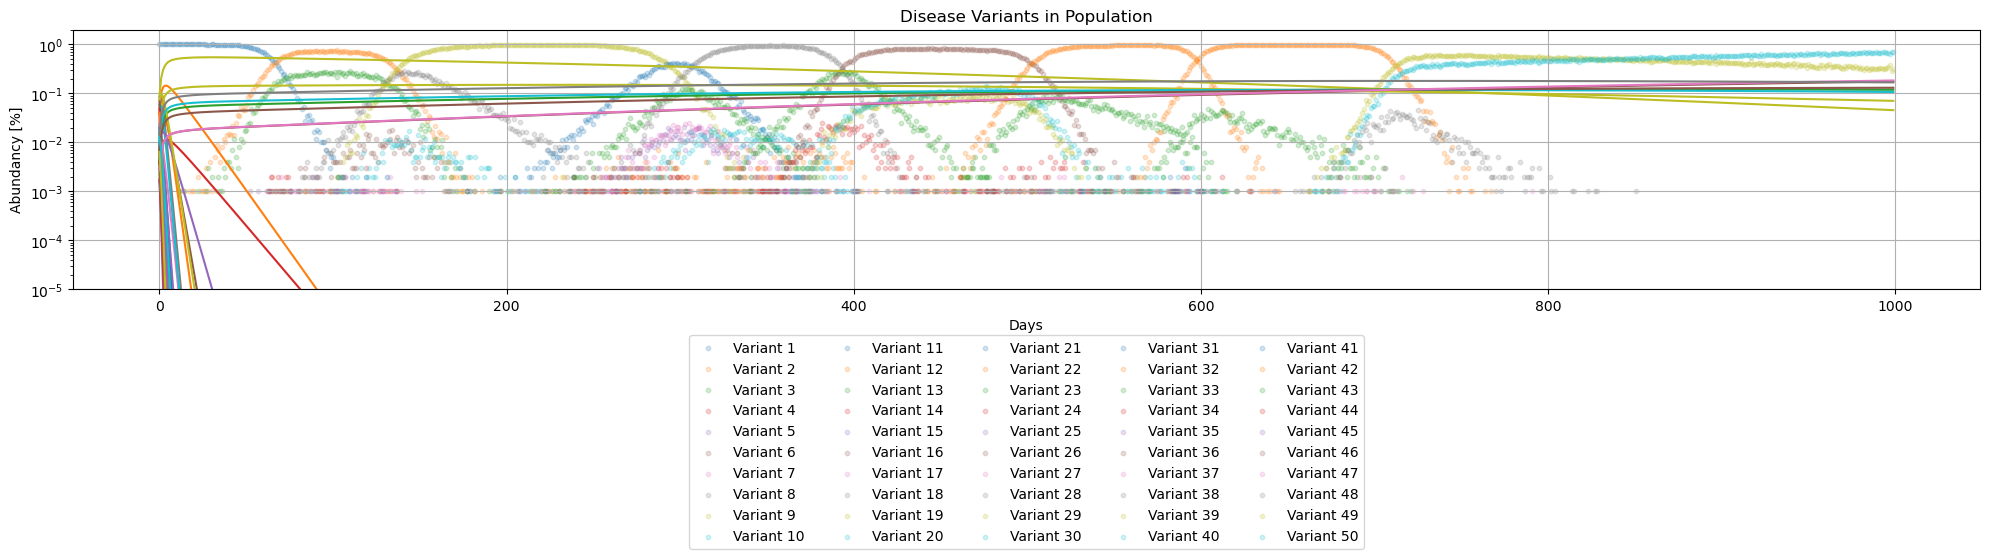

In [43]:
o_vec = np.median(posterior.samples['beta'][:,0,:], axis = 0)
s_vec = np.median(posterior.samples['beta'][:,1,:], axis = 0)
freq_estimate = np.median(posterior.samples['freq'], axis = 0)

composition_estimate = calculate_frequencies(data['counts'].shape[0], s_vec, o_vec) #maybe log scale

plot_viral_composition(data['counts'], freq_estimate, n_samples, logscale = False)
plot_viral_composition(data['counts'], freq_estimate, n_samples, y_range = (1e-5, 2), logscale = True)

In [45]:
freq_estimate.shape

(1000, 50)

In [41]:
freq_estimate[999]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.17565723, 0.        , 0.        , 0.04558859, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.07054868, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.11866716, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.10714142,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.13060112, 0.18377285, 0.16802299, 0.        , 0.        ],
      dtype=float32)

In [29]:
np.mean(o_vec, axis = 0).shape

(50,)

In [23]:
posterior.samples.keys()

dict_keys(['beta', 'freq', 'ga', 'raw_beta', 'seq_counts'])

In [16]:
posterior.samples['beta'].shape

(1000, 2, 50)

In [25]:
posterior.samples['beta'][0,0,:]
# last variant is fixed as pivot (but I specified variant_0)
# first beta variable might be o, second beta variable might be s --> still both have quite a weird parameter range

Array([-1.0451697 ,  1.395137  , -0.34663248, -0.7737511 , -1.9459056 ,
       -1.5204524 , -1.2218283 , -0.9424517 ,  1.9756472 , -1.008444  ,
        0.67109317, -0.5752178 , -1.6876059 , -1.1990594 , -0.13212724,
        1.1785439 , -0.1961009 ,  1.9142407 ,  0.55898106,  1.5475127 ,
        0.51099825,  1.795107  ,  0.21717817, -1.9999905 , -0.23611784,
        1.7331364 ,  1.1364396 , -0.1492314 , -1.7502851 , -1.5337994 ,
        0.46825013, -1.4641848 , -0.39013168,  1.3435678 , -0.35064158,
       -0.45547116,  0.8597508 , -1.4234126 ,  1.7939262 , -0.21062912,
       -0.92798734,  1.182867  , -1.1803964 , -1.109797  , -0.6826666 ,
       -0.6946152 , -1.5143676 ,  0.14787194, -0.66419274,  0.        ],      dtype=float32)

In [32]:
posterior.samples['beta'][:, 0, :] # parameter estimates: 0 - log_initial_freq, 1 - growth_rate

Array([[-3.7492523, -4.668959 , -4.8894596, -6.240641 ,  0.       ],
       [-3.7525878, -4.6650157, -4.8914247, -6.2417226,  0.       ],
       [-3.7304926, -4.657724 , -4.908399 , -6.224847 ,  0.       ],
       ...,
       [-3.808371 , -4.650501 , -4.8977256, -6.236237 ,  0.       ],
       [-3.7680986, -4.626996 , -4.8750324, -6.1623793,  0.       ],
       [-3.7567308, -4.6922016, -4.926514 , -6.248144 ,  0.       ]],      dtype=float32)

In [33]:
# Use posterior beta to forecast posterior frequenicies. forecast_L defines the number of infection periods to predict in the future

forecast_L = 50
posterior_10.samples = mlr.forecast_frequencies(posterior_10.samples, forecast_L)

In [65]:
posterior.samples.keys()

dict_keys(['beta', 'freq', 'ga', 'raw_beta', 'seq_counts', 'freq_forecast', 'delta_bar'])

In [74]:
posterior.samples['ga'].shape

(1000, 4)

In [73]:
posterior.samples['beta'][:, 0, 0]

Array([-3.7492523, -3.7525878, -3.7304926, -3.7616706, -3.743676 ,
       -3.8027978, -3.7968078, -3.7657046, -3.7452812, -3.740536 ,
       -3.7505655, -3.7451563, -3.8156805, -3.799399 , -3.82881  ,
       -3.8283944, -3.7560563, -3.7898529, -3.7797444, -3.77542  ,
       -3.7833078, -3.7466803, -3.7874985, -3.7882984, -3.762165 ,
       -3.7559254, -3.7699482, -3.7937052, -3.7796865, -3.7797542,
       -3.7816784, -3.7653859, -3.7311997, -3.7068331, -3.7888122,
       -3.7545528, -3.7714946, -3.771585 , -3.7649338, -3.7746465,
       -3.7767546, -3.7767286, -3.7771513, -3.7681189, -3.7741349,
       -3.7819333, -3.780682 , -3.7432728, -3.84016  , -3.7379055,
       -3.750462 , -3.7483878, -3.753058 , -3.7521203, -3.7666132,
       -3.7684743, -3.7164881, -3.8308246, -3.7640736, -3.7632277,
       -3.7533567, -3.7710338, -3.765516 , -3.7215476, -3.7169497,
       -3.7233284, -3.7641723, -3.7648146, -3.7805948, -3.7800114,
       -3.7763286, -3.7826512, -3.7682946, -3.731045 , -3.7639

In [37]:
posterior.save_posterior("data/mlr_estimates.pkl")
# Loading new posterior
loaded_posterior = ef.PosteriorHandler(data=variant_frequencies).load_posterior("data/mlr_estimates.pkl")

### Plot results

In [22]:
def prepare_count_data_evofr(counts_df):
    
    start_date = pd.to_datetime("2025-01-01")
    dates = [start_date + pd.Timedelta(days=day - 1) for day in counts_df.day]

    counts_df['day'] = dates

    counts_df = counts_df.rename(columns = {"day": "date", "count": "sequences"})

    return counts_df

In [30]:
counts_df_test = pd.read_csv("../evofr/test/testing_data/mlr-variant-counts.tsv", sep = "\t")

In [31]:
counts_df_test

,variant,sequences,date,location
0,C,15,2022-01-01,City0
1,C,15,2022-01-02,City0
2,A,1,2022-01-03,City0
3,C,14,2022-01-03,City0
4,C,15,2022-01-04,City0
...,...,...,...,...
323,A,2,2022-03-09,City1
324,B,18,2022-03-09,City1
325,A,1,2022-03-10,City1
326,B,19,2022-03-10,City1


In [40]:
# Assuming your DataFrame is named df
count_matrix = counts_df_test.pivot_table(
    index='date',
    columns='variant',
    values='sequences',
    aggfunc='sum',
    fill_value=0
)
counts_array = count_matrix.to_numpy()
counts_array.shape

#composition_estimate = calculate_frequencies(counts_array.shape[0], s_vec, o_vec) #maybe log scale


(70, 3)

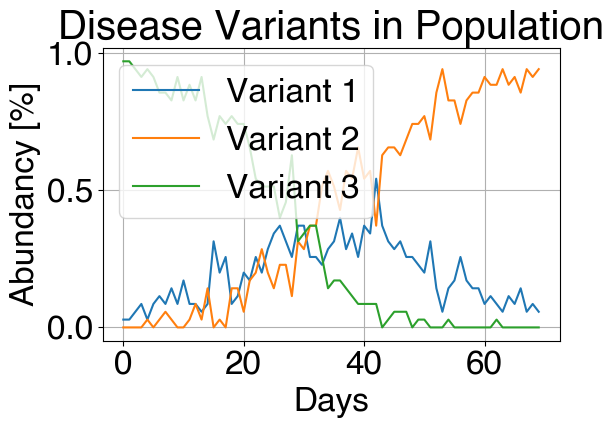

In [44]:
# Plot each variant
def plot_variants(counts):

    day_sums = np.sum(counts, axis = 1)

    for i in range(counts.shape[1]):
        plt.plot(np.arange(counts.shape[0]), counts[:, i] / day_sums[i], label = f'Variant {i+1}') 

    plt.xlabel("Days")
    plt.ylabel("Abundancy [%]")
    plt.title("Disease Variants in Population")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_variants(counts_array)


In [23]:
counts_df = pd.read_csv("data/counts_5var_180day.csv")
counts_df = prepare_count_data_evofr(counts_df)
counts_df.head()

,date,variant,sequences
0,2024-12-31,variant_0,917
1,2025-01-01,variant_0,906
2,2025-01-02,variant_0,900
3,2025-01-03,variant_0,904
4,2025-01-04,variant_0,889


In [24]:
counts_df.variant.unique()

array(['variant_0', 'variant_1', 'variant_2', 'variant_3', 'variant_4'],
      dtype=object)

In [25]:
variant_frequencies = ef.VariantFrequencies(counts_df, pivot="variant_0")

mlr = ef.MultinomialLogisticRegression(tau=1) # tau: average generation time (1 day)
inference_method = ef.InferNUTS(num_samples=1000, num_warmup=1000) # num_warmup defines burn in

posterior = inference_method.fit(mlr, variant_frequencies)

sample: 100%|██████████| 2000/2000 [00:30<00:00, 65.96it/s, 1023 steps of size 7.91e-08. acc. prob=0.85]


In [26]:
forecast_L = 50
posterior.samples = mlr.forecast_frequencies(posterior.samples, forecast_L)

In [27]:
posterior.samples['beta'].shape

(1000, 2, 5)

In [28]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.patches as mpatches

font = {'family' : 'Helvetica',
        'weight' : 'light',
        'size'   : 24}

matplotlib.rc('font', **font)

from evofr.plotting import FrequencyPlot, GrowthAdvantagePlot, PatchLegend, add_dates_sep
from evofr.plotting import plot_site_in_time, plot_variants, plot_time_series_with_variants

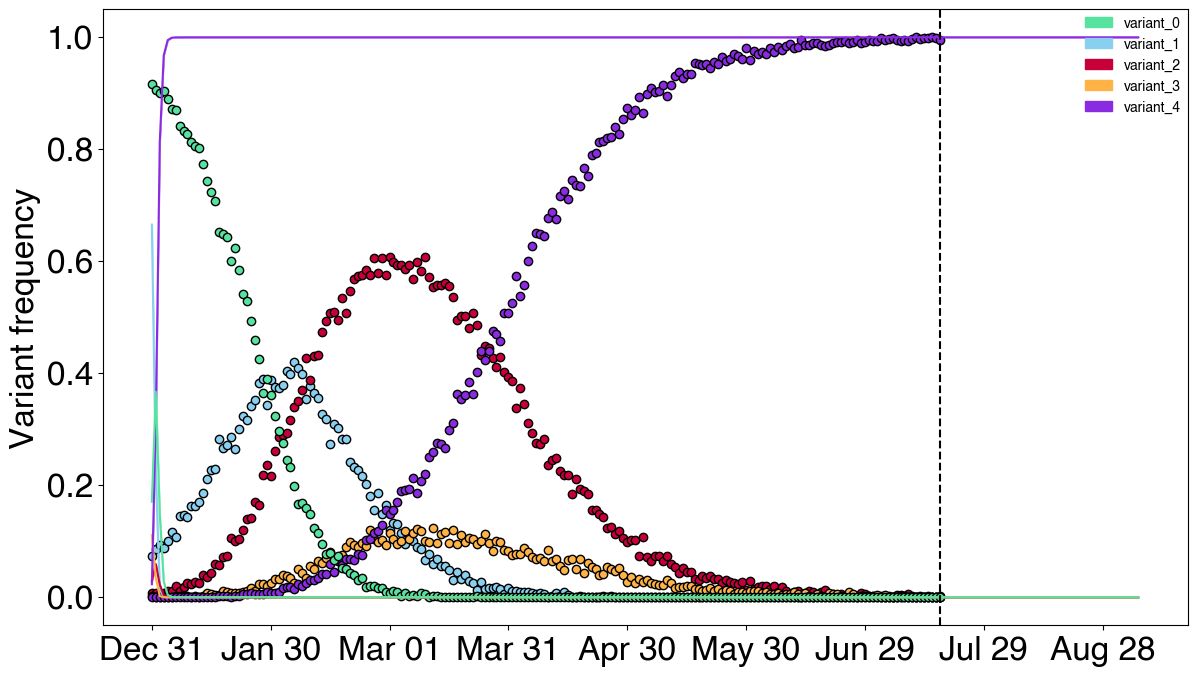

In [29]:
v_colors = ["#56e39f", "#89CFF0", "#C70039", "#FFB347", "#8A2BE2"]
v_names = list(counts_df.variant.unique())
color_map = {v: c for c, v in zip(v_colors, v_names)}

# Plot predicted frequencies
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(nrows=1, ncols=1)
ax = fig.add_subplot(gs[0,0])

FrequencyPlot(posterior, color_map=color_map).plot(ax, forecast=True)
ax.axvline(x=len(variant_frequencies.dates)-1, color='k', linestyle='--') # Adding forecast cut off
add_dates_sep(ax, ef.data.expand_dates(variant_frequencies.dates, forecast_L), sep=30) # Adding dates

ax.legend(
    handles=[
        mpatches.Patch(color=c, label=v) for v, c in color_map.items()
    ],
    loc='upper right',
    fontsize=10,
    frameon=False,
    ncol=1,  # single column
    borderaxespad=0.1
)

#PatchLegend(color_map, ncol=5).add_legend(ax)


#fig.tight_layout()

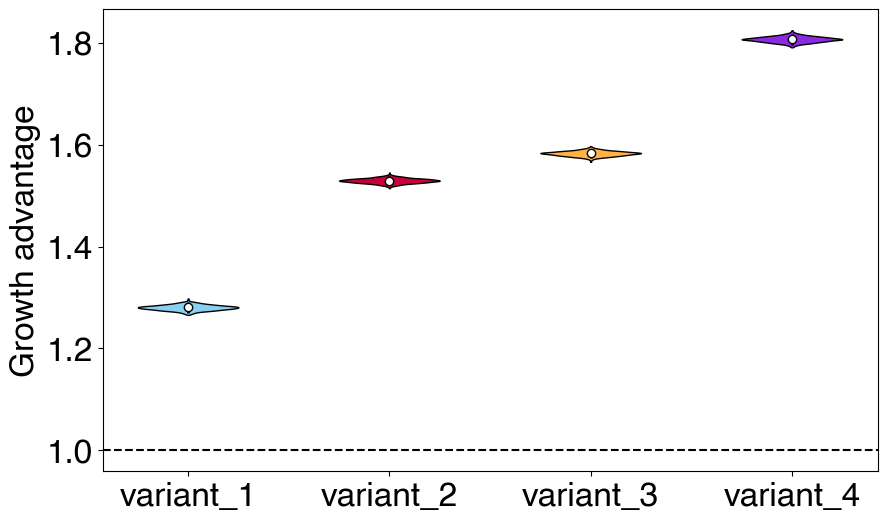

In [56]:
# Plotting growth advantage
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(nrows=1, ncols=1)
ax = fig.add_subplot(gs[0,0])

GrowthAdvantagePlot(posterior, color_map=color_map).plot(ax=ax)

Text(0, 0.5, 'Mean fitness')

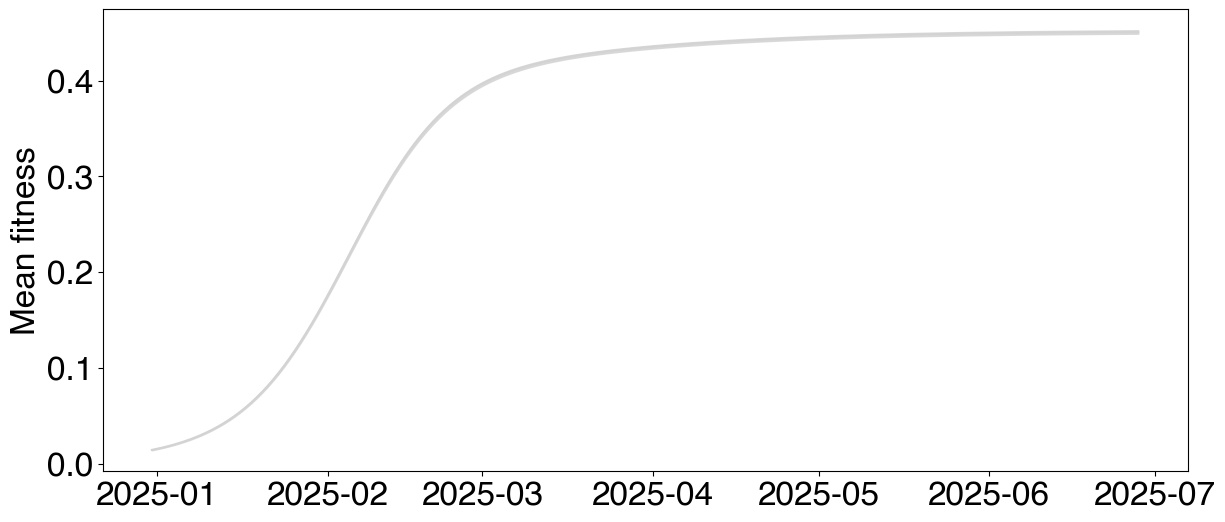

In [57]:
# Computing and plotting mean fitness using `plot_site_in_time` primitive
fig, ax = plt.subplots(figsize=(14,6))
posterior.samples["delta_bar"] = (posterior.samples["freq"][:, :, :-1] * posterior.samples["ga"][:, None, :]).mean(axis=-1)
plot_site_in_time(ax, posterior.samples, "delta_bar", dates = posterior.data.dates, alphas=[0.8], colors="lightgray", quantiles=[0.8])
ax.set_ylabel("Mean fitness")

Text(0, 0.5, 'Growth Advantage')

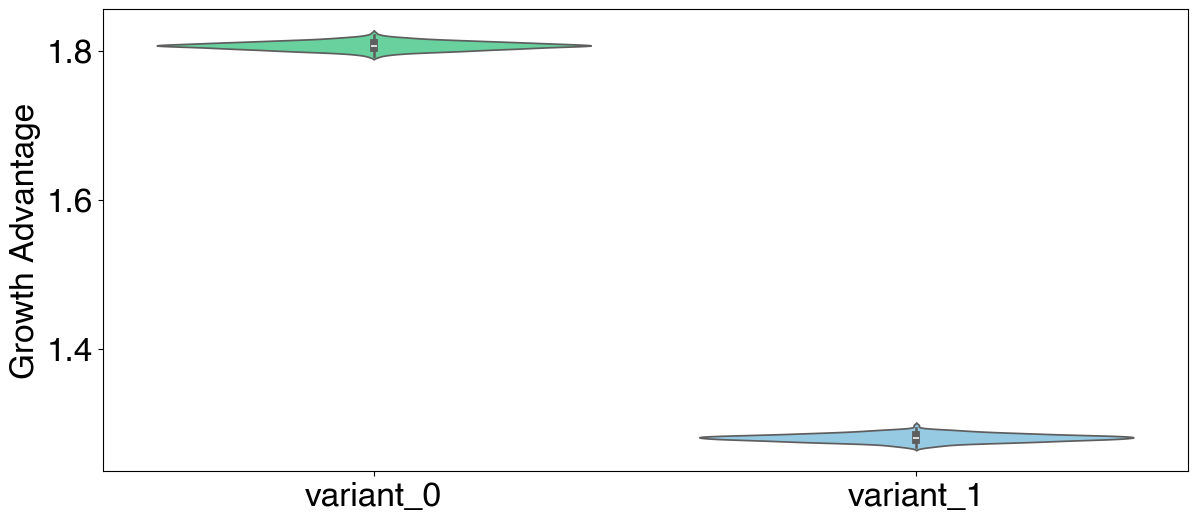

In [59]:
# Plotting growth advantage using `plot_variants` primitive
fig, ax = plt.subplots(figsize=(14,6))
plot_variants(ax, 
              posterior.samples, 
              "ga", 
              color_map=color_map, 
              variants=posterior.data.var_names, 
              variants_to_plot = ["variant_0", "variant_1"])
ax.set_ylabel("Growth Advantage")

In [22]:
posterior.samples["freq"]

Array([[[0.00436604, 0.05010713, 0.00877927, ..., 0.01439525,
         0.00639063, 0.0124165 ],
        [0.00276458, 0.10336266, 0.00199053, ..., 0.03335522,
         0.00139726, 0.00693327],
        [0.00108098, 0.13166733, 0.0002787 , ..., 0.04772637,
         0.00018865, 0.00239071],
        ...,
        [0.        , 0.        , 0.        , ..., 0.16817677,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.16809304,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.16802299,
         0.        , 0.        ]],

       [[0.00436604, 0.05010713, 0.00877927, ..., 0.01439525,
         0.00639063, 0.0124165 ],
        [0.00276458, 0.10336266, 0.00199053, ..., 0.03335522,
         0.00139726, 0.00693327],
        [0.00108098, 0.13166733, 0.0002787 , ..., 0.04772637,
         0.00018865, 0.00239071],
        ...,
        [0.        , 0.        , 0.        , ..., 0.16817677,
         0.        , 0.        ],
        [0. 

Text(0, 0.5, 'Variant Frequency')

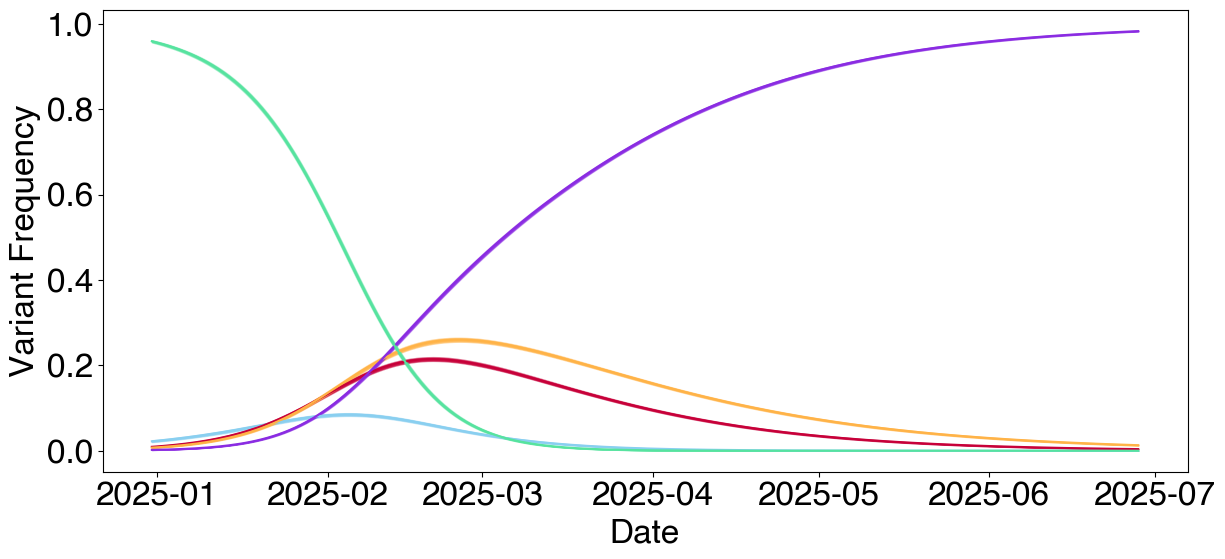

In [60]:
# Plotting variant frequency using `plot_time_series_with_variants` primitive
fig, ax = plt.subplots(figsize=(14,6))
plot_time_series_with_variants(ax, 
                               posterior.samples, "freq", 
                               variants=posterior.data.var_names, 
                               dates = posterior.data.dates,               
                               color_map=color_map, 
                               alphas = [0.5, 0.7],
                               quantiles=[0.99, 0.8]
)
ax.set_ylabel("Variant Frequency")